# MAGICC7

Pymagicc is also MAGICC7 compatible. 

As yet, the binary is not yet publicly available to it's a bit fiddlier to get setup. Here we give a minimal working example of how to use MAGICC7 with Pymagicc.

In [1]:
# NBVAL_IGNORE_OUTPUT
import os

import pandas as pd
import pymagicc
from pymagicc import MAGICC6, MAGICC7
from pymagicc.io import MAGICCData

from pymagicc import scenarios

/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/scmdata/database/_database.py:9: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  import tqdm.autonotebook as tqdman


In [2]:
# NBVAL_IGNORE_OUTPUT
%matplotlib inline
from matplotlib import pyplot as plt

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = 16, 9

In [3]:
# NBVAL_SKIP
# set your environment to find your MAGICC binary
%env MAGICC_EXECUTABLE_7=/Users/seangtkelley/Source/blog-posts/climate-model-magicc-python/magicc-v7.5.3/bin/magicc-darwin-arm64

env: MAGICC_EXECUTABLE_7=/Users/seangtkelley/Source/blog-posts/climate-model-magicc-python/magicc-v7.5.3/bin/magicc-darwin-arm64


If you encounter an error complaining about `libgfortran`, you likely also need to specify a path for the this library.

On MacOS, this will likely be be in your `gcc` install, but you can find its full path with the following command:
`find /path/to/search -name "libgfortran*.dylib"`

In [4]:
# NBVAL_SKIP
%env DYLD_LIBRARY_PATH=/opt/homebrew/Cellar/gcc/14.2.0_1/lib/gcc/current:$DYLD_LIBRARY_PATH

env: DYLD_LIBRARY_PATH=/opt/homebrew/Cellar/gcc/14.2.0_1/lib/gcc/current:$DYLD_LIBRARY_PATH


## The slow, easy way

Use the `pymagicc.run` API. This is super slow as it makes a new copy of the entire `magicc/run` directory for each run.

A few common issues when using your own setup are:
    - output flag settings may mean that you don't get the output you expect
    - super slow running as lots of output are being read back in (turn `OUT_XX` flags off to speed things up)
    - super slow running as your `out` directory is not empty before you run
    - your config file has more than one emissions scenario and/or config flag set (Pymagicc deliberately throws an error here to avoid difficult debugging of overlapping emissions and config inputs)
    
`MAGCFG_USER.CFG` should have lines like

```makefile
  FILE_EMISSCEN =  "NONE",
  FILE_EMISSCEN_2 =  "",
  FILE_EMISSCEN_3 =  "",
  FILE_EMISSCEN_4 =  "",
  FILE_EMISSCEN_5 =  "",
  FILE_EMISSCEN_6 =  "",
  FILE_EMISSCEN_7 =  "",
  FILE_EMISSCEN_8 =  "",
  FILE_TUNINGMODEL_1 =  "PYMAGICC",
  FILE_TUNINGMODEL_2 =  "USER",
  FILE_TUNINGMODEL_3 =  "USER",
  FILE_TUNINGMODEL_4 =  "USER",
  FILE_TUNINGMODEL_5 =  "USER",
  FILE_TUNINGMODEL_6 =  "USER",
  FILE_TUNINGMODEL_7 =  "USER",
  FILE_TUNINGMODEL_8 =  "USER",
  FILE_TUNINGMODEL_9 =  "USER",
  FILE_TUNINGMODEL_10 =  "USER",
  # at least one `OUT_` variable must be set to 1 to produce output
  # for this notebook, since we only plot temperature, we only need OUT_TEMPERATURE
  OUT_TEMPERATURE = 1,
```

In [5]:
# NBVAL_SKIP
scenario_names = list(map(str.lower, scenarios.rcps.meta["scenario"].unique()))
scenario_names

['rcp26', 'rcp45', 'rcp60', 'rcp85']

In [6]:
# NBVAL_SKIP
for i, name in enumerate(scenario_names):
    print("running {}".format(name))
    scen = getattr(scenarios, name)
    scen_results = pymagicc.run(scen, magicc_version=7)
    if i != 0:
        results = results.append(scen_results)
    else:
        results = scen_results

running rcp26


/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warnings.warn(warn_msg)
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warnings.warn(warn_msg)
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/core.py:436: UserWarning: magicc logged a ERROR message. Check the 'stderr' key of the result's `metadata` attribute.
  warnings.warn(


running rcp45


/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warnings.warn(warn_msg)
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warnings.warn(warn_msg)
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/core.py:436: UserWarning: magicc logged a ERROR message. Check the 'stderr' key of the result's `metadata` attribute.
  warnings.warn(


running rcp60


/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warnings.warn(warn_msg)
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warnings.warn(warn_msg)
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/core.py:436: UserWarning: magicc logged a ERROR message. Check the 'stderr' key of the result's `metadata` attribute.
  warnings.warn(


running rcp85


/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warnings.warn(warn_msg)
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warnings.warn(warn_msg)
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/core.py:436: UserWarning: magicc logged a ERROR message. Check the 'stderr' key of the result's `metadata` attribute.
  warnings.warn(


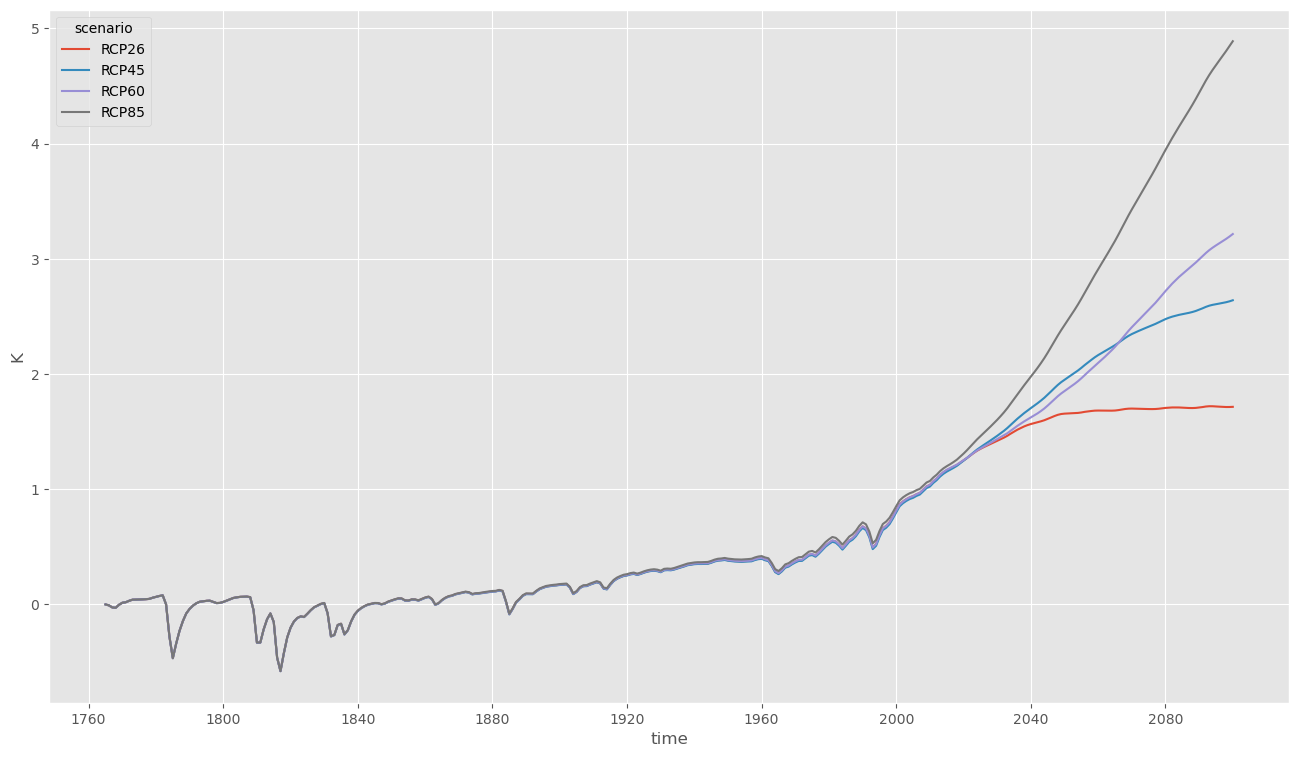

In [7]:
# NBVAL_SKIP
results.filter(variable="Surface Temperature", region="World").line_plot(
    x="time"
);

## The faster, mildly more difficult way

Use the context manager for the MAGICC version we want. This still creates a copy of the entire run folder, but only once.

running rcp26


/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warnings.warn(warn_msg)
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warnings.warn(warn_msg)
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/core.py:436: UserWarning: magicc logged a ERROR message. Check the 'stderr' key of the result's `metadata` attribute.
  warnings.warn(
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming t

running rcp45


/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/core.py:436: UserWarning: magicc logged a ERROR message. Check the 'stderr' key of the result's `metadata` attribute.
  warnings.warn(
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warnings.warn(warn_msg)
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warnings.warn(warn_msg)


running rcp60


/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/core.py:436: UserWarning: magicc logged a ERROR message. Check the 'stderr' key of the result's `metadata` attribute.
  warnings.warn(
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warnings.warn(warn_msg)
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warnings.warn(warn_msg)


running rcp85


/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/core.py:436: UserWarning: magicc logged a ERROR message. Check the 'stderr' key of the result's `metadata` attribute.
  warnings.warn(


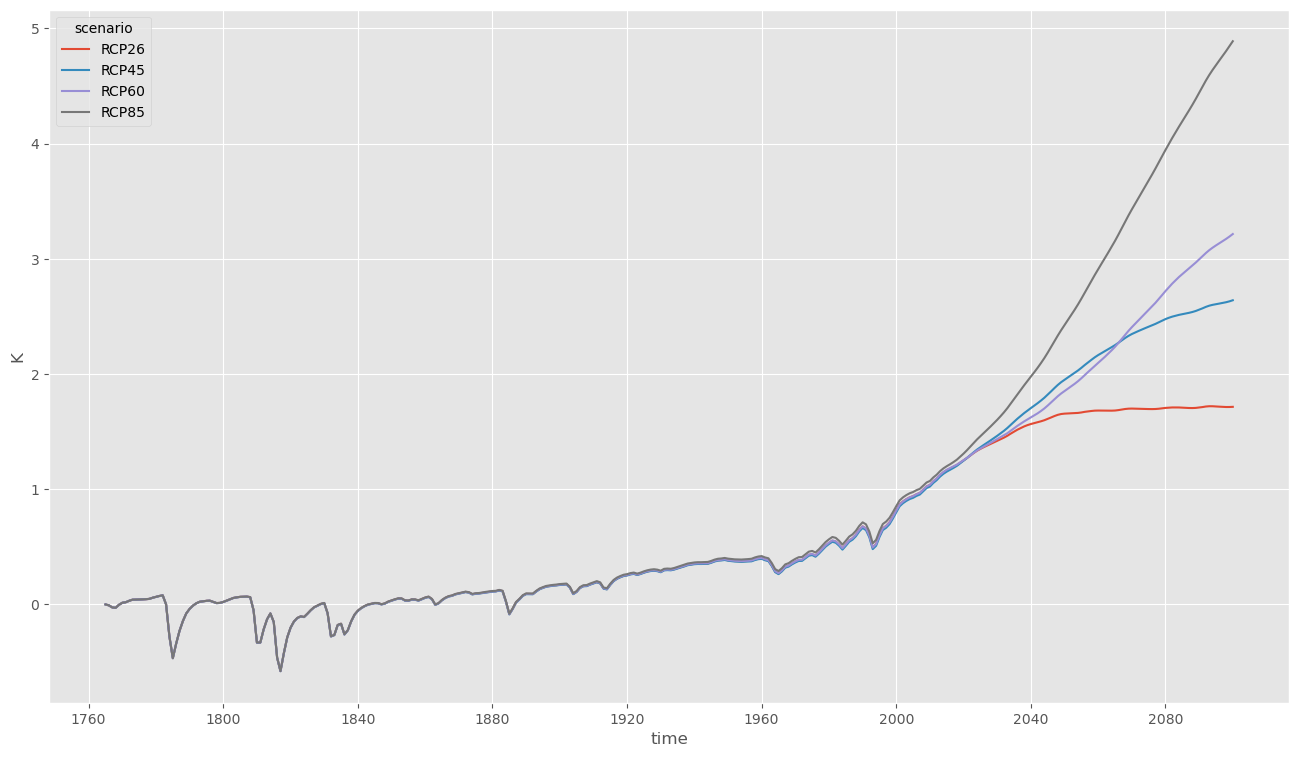

In [8]:
# NBVAL_SKIP
with MAGICC7() as magicc:
    for i, name in enumerate(scenario_names):
        # note that we obviously don't need magicc_version as an argument
        # here as it is assigned automatically
        print("running {}".format(name))
        scen = getattr(scenarios, name)
        scen_results = magicc.run(scen)
        if i != 0:
            results = results.append(scen_results)
        else:
            results = scen_results

results.filter(variable="Surface Temperature", region="World").line_plot(
    x="time"
);

## The even faster, more dangerous and difficult to debug way

Use the context manager for the MAGICC version we want and specify the root directory. This doesn't create a copy of the entire run folder, but will modify files in place and hence alter any existing settings in your local copy.

In [ ]:
# NBVAL_SKIP
exe_path = os.environ.get("MAGICC_EXECUTABLE_7", "../../magicc/run/magicc")
root_dir = os.path.dirname(os.path.dirname(exe_path)) + "-overwrite"
print(root_dir)
with MAGICC7(root_dir=root_dir) as magicc:
    # binary readers aren't yet ready and we can't do this through
    # the run method just yet
    magicc.set_output_variables(
        write_ascii=False,
        write_binary=True,
        keydata_2=True,
        emissions=False,
        parameters=True,
    )
    # for i, name in enumerate(scenario_names):
    #     # note that we obviously don't need magicc_version as an argument
    #     # here as it is assigned automatically
    #     print("running {}".format(name))
    #     scen = getattr(scenarios, name)
    #     scen_results = magicc.run(scen)
    #     if i != 0:
    #         results = results.append(scen_results)
    #     else:
    #         results = scen_results
    results = magicc.run(scenarios.rcps)

results.filter(variable="Surface Temperature", region="World").line_plot(
    x="time"
);

/Users/seangtkelley/Source/blog-posts/climate-model-magicc-python/magicc-v7.5.3-overwrite
running rcp26


/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warnings.warn(warn_msg)
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warnings.warn(warn_msg)


ValueError: You have more than one `FILE_EMISSCEN_X` flag set. Using more than one emissions scenario is hard to debug and unnecessary with Pymagicc's Dataframe scenario input. Please combine all your scenarios into one Dataframe with Pymagicc and Pandas, then feed this single Dataframe into Pymagicc's run API.

## Comparing MAGICC6 and MAGICC7

Finally, we show how to easily compare MAGICC6 and MAGICC7. 

**Note** I've got strange settings in my local MAGICC7 folder so don't read anything into the plots.

In [17]:
# NBVAL_SKIP
for j, mclass in enumerate([MAGICC6, MAGICC7]):
    print("MAGICC{}".format(mclass.version))
    with mclass() as magicc:
        # binary readers aren't yet ready and we can't do this through
        # the run method just yet
        magicc.set_output_variables(
            write_ascii=True,
            write_binary=False,
            keydata_2=True,
            emissions=False,
            parameters=True,
        )
        for i, name in enumerate(scenario_names):
            # note that we obviously don't need magicc_version as an argument
            # here as it is assigned automatically
            print("running {}".format(name))
            scen = getattr(scenarios, name)
            scen_results = magicc.run(scen)
            if i != 0 and j != 0:
                results = results.append(scen_results)
            else:
                results = scen_results

MAGICC6
running rcp26
running rcp45
running rcp60
running rcp85
MAGICC7
running rcp26


/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warnings.warn(warn_msg)
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warnings.warn(warn_msg)
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/core.py:436: UserWarning: magicc logged a WARNING message. Check the 'stderr' key of the result's `metadata` attribute.
  warnings.warn(
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/core.py:436: UserWarning: magicc logged a ERROR message. Check the 'stderr' key of the result's `metadata` attribut

running rcp45


/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/core.py:436: UserWarning: magicc logged a WARNING message. Check the 'stderr' key of the result's `metadata` attribute.
  warnings.warn(
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/core.py:436: UserWarning: magicc logged a ERROR message. Check the 'stderr' key of the result's `metadata` attribute.
  warnings.warn(
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warnings.warn(warn_msg)
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warn

running rcp60


/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/core.py:436: UserWarning: magicc logged a WARNING message. Check the 'stderr' key of the result's `metadata` attribute.
  warnings.warn(
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/core.py:436: UserWarning: magicc logged a ERROR message. Check the 'stderr' key of the result's `metadata` attribute.
  warnings.warn(
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warnings.warn(warn_msg)
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/io/scen7.py:43: UserWarning: MAGICC6 RCP region naming (R5*) is not compatible with MAGICC7, automatically renaming to MAGICC7 compatible regions (R5.2*)
  warn

running rcp85


/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/core.py:436: UserWarning: magicc logged a WARNING message. Check the 'stderr' key of the result's `metadata` attribute.
  warnings.warn(
/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pymagicc/core.py:436: UserWarning: magicc logged a ERROR message. Check the 'stderr' key of the result's `metadata` attribute.
  warnings.warn(


## Plotting options

When plotting climate model output, you often want to plot it with respect to some reference period. Here I propose two options for doing so.

Option 1 would add methods to OpenSCMDataFrame (or IamDataFrame)

In [25]:
!pip install pyam-iamc

  Using cached rich-13.9.4-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-3.0.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached click-8.1.8-py3-none-any.whl.metadata (2.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 8.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 7.7 MB/s eta 0:00:00a 0:00:01
Using cached rich-13.9.4-py3-none-any.whl (242 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 8.0 MB/s eta 0:00:00a 0:00:01
Using cached click-8.1.8-py3-none-any.whl (98 kB)
Using cached markdown_it_py-3.0.0-py3-none-any.whl (87 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 8.1 MB/s eta 0:00:00a 0:00:01
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)


In [21]:
!pip install pycollocation

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pycollocation: filename=pycollocation-0.6.0a0-py2.py3-none-any.whl size=19874 sha256=ec963cfc36bfb4bc3d497bd3823cf52c77d5cd847a54fcb1e6ffee13089e739a
  Stored in directory: /Users/seangtkelley/Library/Caches/pip/wheels/a5/06/0f/23d248c12a8e4bec1bad530b3bf75daaf72a6ee90ef8aef806
Successfully built pycollocation


In [23]:
!pip install sympy

  Using cached sympy-1.13.3-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached sympy-1.13.3-py3-none-any.whl (6.2 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)


In [ ]:
# TODO: remake conda environment clean in case this is importing the wrong pyam
import pyam

In [32]:
# NBVAL_SKIP
# TODO: move into OpenSCMDataFrame or pyam
from pyam.plotting import reshape_line_plot


def get_reference_period_mean(df, reference_period, x="year", y="value"):
    ref_period_start, ref_period_end = reference_period
    assert (
        ref_period_start < ref_period_end
    ), "reference period must go from earlier to later"

    # type assertion on start and end?
    adf = reshape_line_plot(df, x=x, y=y)
    mdf = adf.loc[ref_period_start:ref_period_end].mean()

    return mdf


def adjust_to_baseline(mdata, reference_period, x="time", y="value"):
    ref_period_start, ref_period_end = reference_period
    assert (
        ref_period_start < ref_period_end
    ), "reference period must go from earlier to later"

    adf = reshape_line_plot(mdata.data.copy(), x=x, y=y)
    mdf = get_reference_period_mean(
        mdata.data.copy(), reference_period, x=x, y=y
    )

    bdf = adf - mdf

    ldf = bdf.T.stack(x).reset_index()
    ldf = ldf.rename({0: y}, axis="columns")

    #     # include?
    #     bstr = "{} to {} baseline".format(ref_period_start, ref_period_end)
    #     ldf["variable"] = ldf["variable"].apply(lambda x: "{} ({})".format(x, bstr))

    return MAGICCData(ldf)


def highlight_reference_period(ax, reference_period, **kwargs):
    ref_period_start, ref_period_end = reference_period
    assert (
        ref_period_start < ref_period_end
    ), "reference period must go from earlier to later"

    ax.axvspan(ref_period_start, ref_period_end, **kwargs)

    an_point_x = ref_period_start + (ref_period_end - ref_period_start) * 0.02
    (ymin, ymax) = ax.get_ylim()
    an_point_y = ymin + (ymax - ymin) * 0.01

    ax.annotate("Reference period", xy=(an_point_x, an_point_y))


def add_ylabel(ax, variable, unit, reference_period=None):
    ylabel = "{} ({})".format(variable, unit)

    if reference_period is not None:
        ref_period_start, ref_period_end = reference_period
        assert (
            ref_period_start < ref_period_end
        ), "reference period must go from earlier to later"
        ylabel = "{}\n(reference period: {} - {})".format(
            ylabel, ref_period_start, ref_period_end
        )

    ax.set_ylabel(ylabel)

    return ax


def line_plot(
    magiccdata,
    reference_period=None,
    x="time",
    y="value",
    highlight_kwargs={},
    **kwargs,
):
    if reference_period is not None:
        bdf = adjust_to_baseline(magiccdata, reference_period, x=x, y=y)
        ax = bdf.line_plot(x=x, y=y, **kwargs)
        highlight_reference_period(ax, reference_period, **highlight_kwargs)
    else:
        magiccdata.line_plot(**kwargs)

    add_ylabel(
        ax,
        magiccdata["variable"].iloc[0],
        magiccdata["unit"].iloc[0],
        reference_period,
    )

ImportError: cannot import name 'reshape_line_plot' from 'pyam.plotting' (/Users/seangtkelley/miniconda3/envs/climate-model-pymagicc/lib/python3.13/site-packages/pyam/plotting.py)

In [29]:
# NBVAL_SKIP
from datetime import datetime

line_plot(
    results.filter(variable="Surface Temperature", region="World"),
    (datetime(1850, 1, 1), datetime(1900, 1, 1)),
    highlight_kwargs={"color": "grey", "alpha": 0.5},
    color="scenario",
    marker="climate_model",
)

NameError: name 'line_plot' is not defined

Option 2 uses seaborn instead:

In [30]:
# NBVAL_SKIP
import seaborn as sns

In [33]:
# NBVAL_SKIP
tempdf = results.filter(variable="Surface Temperature", region="World")
ref_period = (datetime(1850, 1, 1), datetime(1900, 1, 1))
bdf = adjust_to_baseline(tempdf, ref_period,)
fg = sns.relplot(
    x="time",
    y="value",
    kind="line",
    hue="scenario",
    style="climate_model",
    data=bdf.data,
)
ax = fg.axes[0][0]
highlight_reference_period(ax, ref_period, **{"color": "grey", "alpha": 0.5})
add_ylabel(ax, bdf["variable"].iloc[0], bdf["unit"].iloc[0], ref_period);

NameError: name 'adjust_to_baseline' is not defined